
QUANTUM CIRCUIT
q0: --[H]--------------●-------
q1: ------------[X]----X-------

CIRCUIT OPERATIONS
Node 0: H(q0)
Node 1: X(q1)
Node 2: CX(q0,q1)

DAG

Node 0: H(q0)
  Parents : []
  Children: [2]

Node 1: X(q1)
  Parents : []
  Children: [2]

Node 2: CX(q0,q1)
  Parents : [0, 1]
  Children: []

TOPOLOGICAL ORDER
Node 0: H(q0)
Node 1: X(q1)
Node 2: CX(q0,q1)


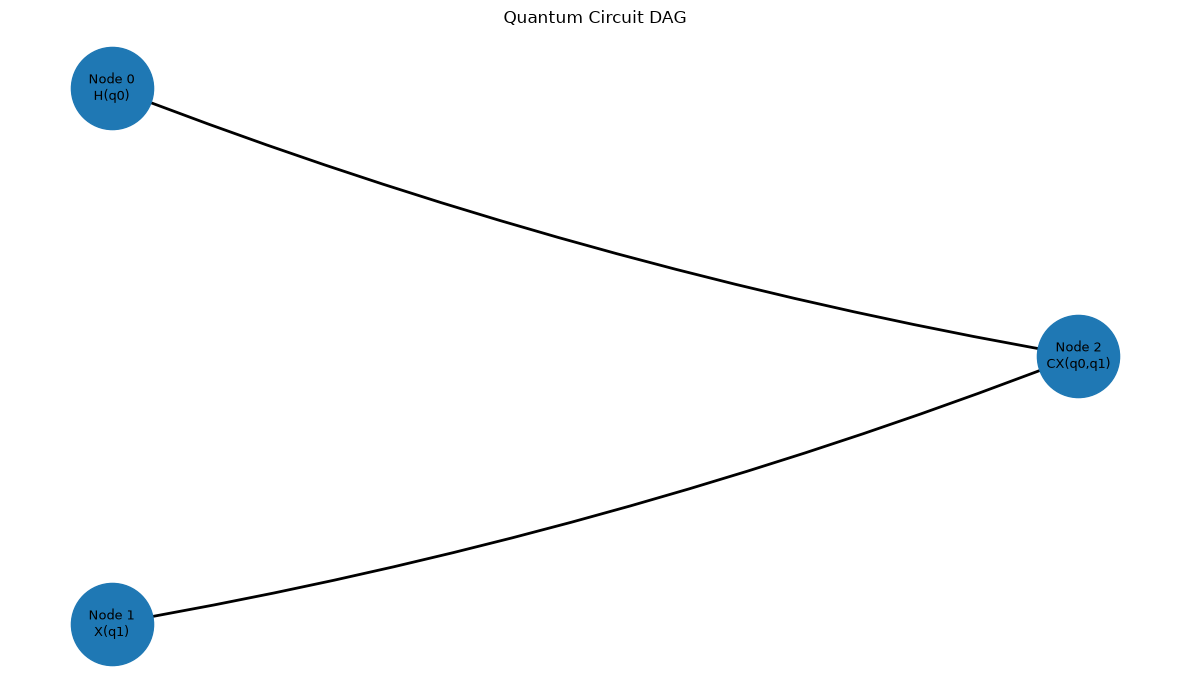

In [19]:
from dataclasses import dataclass
import networkx as nx
import matplotlib.pyplot as plt


# ============================================================
# 1. OPERATION REPRESENTATION
# ============================================================

@dataclass
class Operation:

    id: int
    name: str
    qubits: tuple

    def __repr__(self):

        qubits = ",".join(
            f"q{q}"
            for q in self.qubits
        )

        return f"{self.name}({qubits})"


# ============================================================
# 2. QUANTUM CIRCUIT
# ============================================================

class QuantumCircuit:

    def __init__(self, n_qubits):

        self.n_qubits = n_qubits

        # Stores all quantum operations
        self.operations = []


    # --------------------------------------------------------
    # Add generic operation
    # --------------------------------------------------------

    def add_operation(self, name, *qubits):

        # Validate qubits

        for q in qubits:

            if q < 0 or q >= self.n_qubits:

                raise ValueError(
                    f"Invalid qubit q{q}"
                )


        operation = Operation(

            id=len(self.operations),

            name=name,

            qubits=tuple(qubits)

        )

        self.operations.append(operation)


    # --------------------------------------------------------
    # Single-qubit gates
    # --------------------------------------------------------

    def h(self, qubit):

        self.add_operation(
            "H",
            qubit
        )


    def x(self, qubit):

        self.add_operation(
            "X",
            qubit
        )


    def z(self, qubit):

        self.add_operation(
            "Z",
            qubit
        )


    # --------------------------------------------------------
    # Two-qubit gates
    # --------------------------------------------------------

    def cx(self, control, target):

        self.add_operation(
            "CX",
            control,
            target
        )


    def swap(self, q0, q1):

        self.add_operation(
            "SWAP",
            q0,
            q1
        )


    # --------------------------------------------------------
    # Three-qubit gate
    # --------------------------------------------------------

    def ccx(self, control1, control2, target):

        self.add_operation(
            "CCX",
            control1,
            control2,
            target
        )


    # ========================================================
    # PRINT OPERATIONS
    # ========================================================

    def show_operations(self):

        print("\n" + "=" * 50)

        print("CIRCUIT OPERATIONS")

        print("=" * 50)

        for operation in self.operations:

            print(
                f"Node {operation.id}: "
                f"{operation}"
            )


    # ========================================================
    # DRAW QUANTUM CIRCUIT
    # ========================================================

    def draw(self):

        print("\n" + "=" * 50)

        print("QUANTUM CIRCUIT")

        print("=" * 50)


        # Start each qubit wire

        lines = [

            f"q{i}: "
            for i in range(self.n_qubits)

        ]


        # Process operations

        for operation in self.operations:

            name = operation.name

            qubits = operation.qubits


            # ------------------------------------------------
            # Single qubit gate
            # ------------------------------------------------

            if len(qubits) == 1:

                target = qubits[0]


                for q in range(self.n_qubits):

                    if q == target:

                        lines[q] += (
                            f"--[{name}]--"
                        )

                    else:

                        lines[q] += (
                            "----------"
                        )


            # ------------------------------------------------
            # CX
            # ------------------------------------------------

            elif name == "CX":

                control = qubits[0]

                target = qubits[1]


                for q in range(self.n_qubits):

                    if q == control:

                        lines[q] += "--●-------"

                    elif q == target:

                        lines[q] += "--X-------"

                    else:

                        lines[q] += "----------"


            # ------------------------------------------------
            # SWAP
            # ------------------------------------------------

            elif name == "SWAP":

                q0 = qubits[0]

                q1 = qubits[1]


                for q in range(self.n_qubits):

                    if q == q0 or q == q1:

                        lines[q] += "--×-------"

                    else:

                        lines[q] += "----------"


            # ------------------------------------------------
            # CCX / Toffoli
            # ------------------------------------------------

            elif name == "CCX":

                control1 = qubits[0]

                control2 = qubits[1]

                target = qubits[2]


                for q in range(self.n_qubits):

                    if q == control1:

                        lines[q] += "--●-------"

                    elif q == control2:

                        lines[q] += "--●-------"

                    elif q == target:

                        lines[q] += "--⊕-------"

                    else:

                        lines[q] += "----------"


            # ------------------------------------------------
            # Unknown gate
            # ------------------------------------------------

            else:

                for q in range(self.n_qubits):

                    lines[q] += "----------"


        # Print

        for line in lines:

            print(line)


# ============================================================
# 3. DAG NODE
# ============================================================

class DAGNode:

    def __init__(self, operation):

        self.operation = operation

        # Incoming edges

        self.parents = set()

        # Outgoing edges

        self.children = set()


    @property
    def id(self):

        return self.operation.id


    def __repr__(self):

        return str(
            self.operation
        )


# ============================================================
# 4. QUANTUM DAG
# ============================================================

class QuantumDAG:

    def __init__(self, n_qubits):

        self.n_qubits = n_qubits

        # Dictionary:
        #
        # node_id → DAGNode

        self.nodes = {}


    # --------------------------------------------------------
    # Add node
    # --------------------------------------------------------

    def add_node(self, operation):

        node = DAGNode(
            operation
        )

        self.nodes[
            operation.id
        ] = node


        return node


    # --------------------------------------------------------
    # Add directed edge
    # --------------------------------------------------------

    def add_edge(
        self,
        parent_id,
        child_id
    ):

        parent = self.nodes[
            parent_id
        ]

        child = self.nodes[
            child_id
        ]


        # Parent → child

        parent.children.add(
            child_id
        )

        child.parents.add(
            parent_id
        )


    # ========================================================
    # PRINT DAG
    # ========================================================

    def print_dag(self):

        print("\n" + "=" * 50)

        print("DAG")

        print("=" * 50)


        for node_id in sorted(
            self.nodes
        ):

            node = self.nodes[
                node_id
            ]


            parents = sorted(
                node.parents
            )

            children = sorted(
                node.children
            )


            print(
                f"\nNode {node.id}: "
                f"{node.operation}"
            )

            print(
                f"  Parents : {parents}"
            )

            print(
                f"  Children: {children}"
            )


    # ========================================================
    # TOPOLOGICAL ORDER
    # ========================================================

    def topological_order(self):

        graph = nx.DiGraph()


        # Add nodes

        for node_id in self.nodes:

            graph.add_node(
                node_id
            )


        # Add edges

        for node_id, node in self.nodes.items():

            for child in node.children:

                graph.add_edge(
                    node_id,
                    child
                )


        order = nx.topological_sort(
            graph
        )


        return list(order)


    # ========================================================
    # PRINT TOPOLOGICAL ORDER
    # ========================================================

    def print_topological_order(self):

        order = self.topological_order()


        print("\n" + "=" * 50)

        print("TOPOLOGICAL ORDER")

        print("=" * 50)


        for node_id in order:

            print(
                f"Node {node_id}: "
                f"{self.nodes[node_id].operation}"
            )


    # ========================================================
    # DRAW DAG
    # ========================================================

    def draw(self):

        graph = nx.DiGraph()


        # ----------------------------------------------------
        # Add nodes
        # ----------------------------------------------------

        for node_id, node in self.nodes.items():

            label = (
                f"Node {node_id}\n"
                f"{node.operation}"
            )

            graph.add_node(

                node_id,

                label=label

            )


        # ----------------------------------------------------
        # Add edges
        # ----------------------------------------------------

        for node_id, node in self.nodes.items():

            for child_id in node.children:

                graph.add_edge(

                    node_id,

                    child_id

                )


        # ----------------------------------------------------
        # Position nodes
        # ----------------------------------------------------

        try:

            order = self.topological_order()

            pos = {}

            # Arrange according to DAG level

            levels = {}

            for node_id in order:

                node = self.nodes[
                    node_id
                ]

                if not node.parents:

                    level = 0

                else:

                    level = max(

                        levels[parent]
                        for parent in node.parents

                    ) + 1


                levels[node_id] = level


            # Group nodes by level

            level_nodes = {}

            for node_id, level in levels.items():

                level_nodes.setdefault(
                    level,
                    []
                ).append(
                    node_id
                )


            # Create coordinates

            for level, nodes in level_nodes.items():

                count = len(nodes)

                for index, node_id in enumerate(nodes):

                    x = level

                    y = (
                        -(index - (count - 1) / 2)
                    )

                    pos[node_id] = (
                        x,
                        y
                    )


        except Exception:

            pos = nx.spring_layout(
                graph,
                seed=42
            )


        # ----------------------------------------------------
        # Labels
        # ----------------------------------------------------

        labels = nx.get_node_attributes(

            graph,

            "label"

        )


        # ----------------------------------------------------
        # Draw
        # ----------------------------------------------------

        plt.figure(
            figsize=(12, 7)
        )


        nx.draw_networkx_nodes(

            graph,

            pos,

            node_size=3500

        )


        nx.draw_networkx_edges(

            graph,

            pos,

            arrows=True,

            arrowsize=25,

            width=2,

            connectionstyle="arc3,rad=0.05"

        )


        nx.draw_networkx_labels(

            graph,

            pos,

            labels=labels,

            font_size=9

        )


        plt.title(
            "Quantum Circuit DAG"
        )


        plt.axis("off")

        plt.tight_layout()

        plt.show()


# ============================================================
# 5. CIRCUIT → DAG
# ============================================================

def circuit_to_dag(circuit):

    dag = QuantumDAG(
        circuit.n_qubits
    )


    # --------------------------------------------------------
    # Last operation touching each qubit
    #
    # Example:
    #
    # last_operation[0] = latest gate on q0
    # last_operation[1] = latest gate on q1
    # --------------------------------------------------------

    last_operation = [

        None

        for _ in range(
            circuit.n_qubits
        )

    ]


    # --------------------------------------------------------
    # Process circuit operations in order
    # --------------------------------------------------------

    for operation in circuit.operations:


        # Add operation as DAG node

        dag.add_node(
            operation
        )


        # ----------------------------------------------------
        # Find dependencies
        # ----------------------------------------------------

        dependencies = set()


        for qubit in operation.qubits:

            previous = (
                last_operation[qubit]
            )


            if previous is not None:

                dependencies.add(
                    previous
                )


        # ----------------------------------------------------
        # Add edges
        # ----------------------------------------------------

        for previous in dependencies:

            dag.add_edge(

                previous,

                operation.id

            )


        # ----------------------------------------------------
        # Update latest operation
        # ----------------------------------------------------

        for qubit in operation.qubits:

            last_operation[qubit] = (
                operation.id
            )


    return dag


# ============================================================
# 6. MAIN
# ============================================================

if __name__ == "__main__":


    # --------------------------------------------------------
    # Create 2-qubit circuit
    # --------------------------------------------------------

    qc = QuantumCircuit(2)


    # Circuit:

    # q0: --H------●--
    #              |
    # q1: ------X--X--

    qc.h(0)

    qc.x(1)

    qc.cx(0, 1)


    # --------------------------------------------------------
    # Draw circuit
    # --------------------------------------------------------

    qc.draw()


    # --------------------------------------------------------
    # Print operations
    # --------------------------------------------------------

    qc.show_operations()


    # --------------------------------------------------------
    # Convert Circuit → DAG
    # --------------------------------------------------------

    dag = circuit_to_dag(
        qc
    )


    # --------------------------------------------------------
    # Print DAG
    # --------------------------------------------------------

    dag.print_dag()


    # --------------------------------------------------------
    # Topological ordering
    # --------------------------------------------------------

    dag.print_topological_order()


    # --------------------------------------------------------
    # Visualize DAG
    # --------------------------------------------------------

    dag.draw()